# Рамановская спектроскопия — классификация, 3 класса

**Задача:** Мультиклассовая классификация (control / endo / exo) по рамановским спектрам мозговой ткани.

**Pipeline:**
1. Загрузка данных + **диагностика датасета**
2. Предобработка (SG → AsLS baseline → area norm)
3. **Визуализации:** сырые спектры, эффект предобработки, outlier-детекция
4. GroupKFold кросс-валидация (без data leakage по животным)
5. Ансамбль (RF + XGBoost + SVM) + подбор гиперпараметров
6. Feature importance

Структура папок dataset.zip:
```
dataset/
├── control/     # Класс 0: контрольные образцы
│   ├── mk1/
│   ├── mk2a/
│   ├── mk2b/
│   └── mk3/
├── endo/        # Класс 1: эндогенная экспрессия HSP70
│   ├── mend1/
│   ├── mend2a/
│   ├── mend2b/
│   └── mend3/
└── exo/         # Класс 2: экзогенная экспрессия HSP70
    ├── mexo1/
    ├── mexo2a/
    ├── mexo2b/
    └── mexo3/

## Шаг 0: Установка библиотек

In [29]:
!pip install xgboost umap-learn shap -q

import os, re, glob, shutil, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import seaborn as sns

from scipy.signal import savgol_filter, find_peaks
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.stats import zscore

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, balanced_accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
import umap
import shap
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

COLORS = {'control': '#2196F3', 'endo': '#FF9800', 'exo': '#4CAF50'}
MARKERS = {'control': 'o', 'endo': 's', 'exo': '^'}

print('Все библиотеки загружены')

Все библиотеки загружены


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ШАГ 0.5: распаковка

In [30]:
ARCHIVE_PATH = '/content/drive/MyDrive/dataset.zip'
BASE_PATH    = '/content/data/'
CLASS_NAMES  = ['control', 'endo', 'exo']
CLASS_LABELS = {c: i for i, c in enumerate(CLASS_NAMES)}
os.makedirs(BASE_PATH, exist_ok=True)


def simplify_dataset_structure(base_path):
    for class_name in CLASS_NAMES:
        class_path = os.path.join(base_path, class_name)
        if not os.path.exists(class_path):
            print(f'{class_path} не найдена'); continue
        subfolders = [d for d in os.listdir(class_path)
                      if os.path.isdir(os.path.join(class_path, d))]
        if not subfolders:
            print(f'{class_name}: уже упрощена'); continue
        moved = 0
        for sf in subfolders:
            sfp = os.path.join(class_path, sf)
            for fn in os.listdir(sfp):
                if fn.endswith('.txt'):
                    shutil.move(os.path.join(sfp, fn),
                                os.path.join(class_path, f'{sf}_{fn}'))
                    moved += 1
            shutil.rmtree(sfp)
        print(f'{class_name}: {moved} файлов')


if not os.path.exists(os.path.join(BASE_PATH, 'control')):
    print('Распаковка...')
    os.system(f'unzip -o "{ARCHIVE_PATH}" -d "{BASE_PATH}"')
else:
    print('Датасет уже распакован')

simplify_dataset_structure(BASE_PATH)

print('\nФайлов по классам:')
for cn in CLASS_NAMES:
    cp = os.path.join(BASE_PATH, cn)
    n  = len(glob.glob(os.path.join(cp, '*.txt'))) if os.path.exists(cp) else 0
    print(f'  {cn:10s}: {n}')

Датасет уже распакован
control: уже упрощена
endo: уже упрощена
exo: уже упрощена

Файлов по классам:
  control   : 80
  endo      : 75
  exo       : 84


## ШАГ 1: Загрузка сырых спектров

In [33]:
# Эту часть пришлось делать с нейронкой из-за проблем с временем выполнения
KNOWN_REGIONS = ['cortex', 'striatum', 'cerebellum']
WAVE_GRID     = np.linspace(400, 3200, 1024)   # общая сетка


def parse_filename(filepath):
    fn    = os.path.basename(filepath)
    parts = fn.replace('.txt', '').split('_')
    return {
        'filename'    : fn,
        'brain_region': next((p for p in parts if p in KNOWN_REGIONS), 'unknown'),
        'animal_id'   : parts[0],
    }


def load_spectrum_raw(filepath):
    data = pd.read_csv(filepath, sep=r'\s+', comment='#',
                       header=None, usecols=[2, 3],
                       names=['Wave', 'Intensity'], engine='c')
    data = data.dropna()
    data = data[np.isfinite(data['Wave']) & np.isfinite(data['Intensity'])]
    if len(data) < 10:
        raise ValueError(f'Мало точек: {len(data)}')
    data = data.sort_values('Wave').reset_index(drop=True)
    w, i = data['Wave'].values, data['Intensity'].values
    return WAVE_GRID.copy(), np.interp(WAVE_GRID, w, i, left=i[0], right=i[-1])


def load_all_data(base_path):
    records = []
    for class_name, label in CLASS_LABELS.items():
        cp    = os.path.join(base_path, class_name)
        files = [f for f in glob.glob(os.path.join(cp, '*.txt'))
                 if 'Average' not in f]
        print(f'{class_name}: {len(files)} файлов')
        for fp in tqdm(files, desc=class_name, leave=False):
            try:
                wave, inten = load_spectrum_raw(fp)
                meta = parse_filename(fp)
                records.append({**meta, 'wave': wave, 'intensity': inten,
                                 'target': label, 'class_name': class_name})
            except Exception as e:
                print(f'{os.path.basename(fp)}: {e}')
    print(f'\nВсего: {len(records)} спектров')
    return records


raw_data = load_all_data(BASE_PATH)

control: 80 файлов


endo: 73 файлов


exo: 84 файлов



Всего: 237 спектров


### ВИЗУАЛИЗАЦИЯ 1: Диагностика датасета

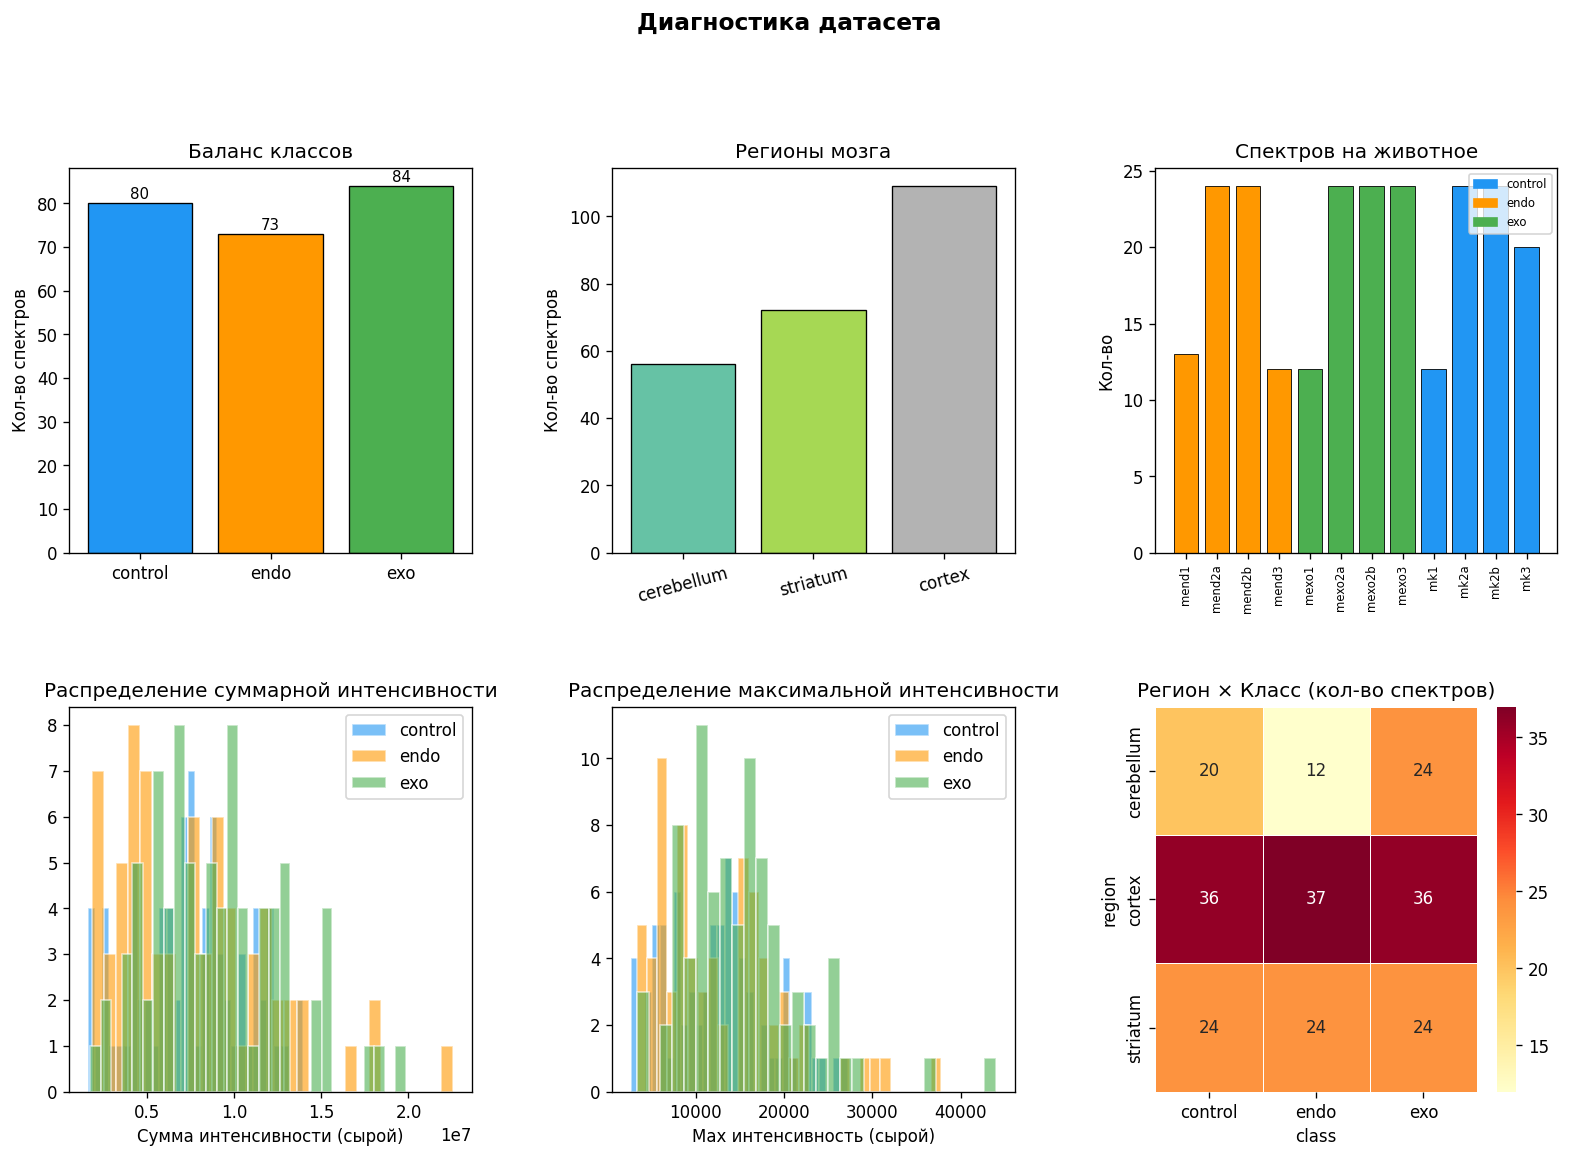

Диагностика датасета


In [48]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# --- 1.1 Баланс классов ---
ax1 = fig.add_subplot(gs[0, 0])
cnt_cls = Counter(r['class_name'] for r in raw_data)
bars = ax1.bar(cnt_cls.keys(), cnt_cls.values(),
               color=[COLORS[k] for k in cnt_cls], edgecolor='black', lw=0.8)
for b in bars:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
             str(int(b.get_height())), ha='center', fontsize=9)
ax1.set_title('Баланс классов')
ax1.set_ylabel('Кол-во спектров')

# --- 1.2 Спектры по регионам мозга ---
ax2 = fig.add_subplot(gs[0, 1])
cnt_reg = Counter(r['brain_region'] for r in raw_data)
reg_colors = plt.cm.Set2(np.linspace(0, 1, len(cnt_reg)))
ax2.bar(cnt_reg.keys(), cnt_reg.values(), color=reg_colors, edgecolor='black', lw=0.8)
ax2.set_title('Регионы мозга')
ax2.set_ylabel('Кол-во спектров')
ax2.tick_params(axis='x', rotation=15)

# --- 1.3 Спектры на животное (мышку) ---
ax3 = fig.add_subplot(gs[0, 2])
animal_counts = Counter(r['animal_id'] for r in raw_data)
animal_class  = {r['animal_id']: r['class_name'] for r in raw_data}
sorted_animals = sorted(animal_counts.keys())
bar_colors_a   = [COLORS[animal_class[a]] for a in sorted_animals]
ax3.bar(range(len(sorted_animals)), [animal_counts[a] for a in sorted_animals],
        color=bar_colors_a, edgecolor='black', lw=0.5)
ax3.set_xticks(range(len(sorted_animals)))
ax3.set_xticklabels(sorted_animals, rotation=90, fontsize=7)
ax3.set_title('Спектров на животное')
ax3.set_ylabel('Кол-во')
patches = [mpatches.Patch(color=COLORS[c], label=c) for c in CLASS_NAMES]
ax3.legend(handles=patches, fontsize=7)

# --- 1.4 Распределение суммарной интенсивности (диагностика выбросов) ---
ax4 = fig.add_subplot(gs[1, 0])
for cn in CLASS_NAMES:
    vals = [r['intensity'].sum() for r in raw_data if r['class_name'] == cn]
    ax4.hist(vals, bins=30, alpha=0.6, label=cn, color=COLORS[cn], edgecolor='white')
ax4.set_title('Распределение суммарной интенсивности')
ax4.set_xlabel('Сумма интенсивности (сырой)')
ax4.legend()

# --- 1.5 Распределение max интенсивности ---
ax5 = fig.add_subplot(gs[1, 1])
for cn in CLASS_NAMES:
    vals = [r['intensity'].max() for r in raw_data if r['class_name'] == cn]
    ax5.hist(vals, bins=30, alpha=0.6, label=cn, color=COLORS[cn], edgecolor='white')
ax5.set_title('Распределение максимальной интенсивности')
ax5.set_xlabel('Max интенсивность (сырой)')
ax5.legend()

# --- 1.6 Регион × Класс heatmap ---
ax6 = fig.add_subplot(gs[1, 2])
pivot = pd.DataFrame([
    {'class': r['class_name'], 'region': r['brain_region']}
    for r in raw_data
]).groupby(['region', 'class']).size().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax6, linewidths=0.5)
ax6.set_title('Регион × Класс (кол-во спектров)')

plt.suptitle('Диагностика датасета', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('dataset_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Диагностика датасета')

### ВИЗУАЛИЗАЦИЯ 2: Сырые спектры — галерея по классам

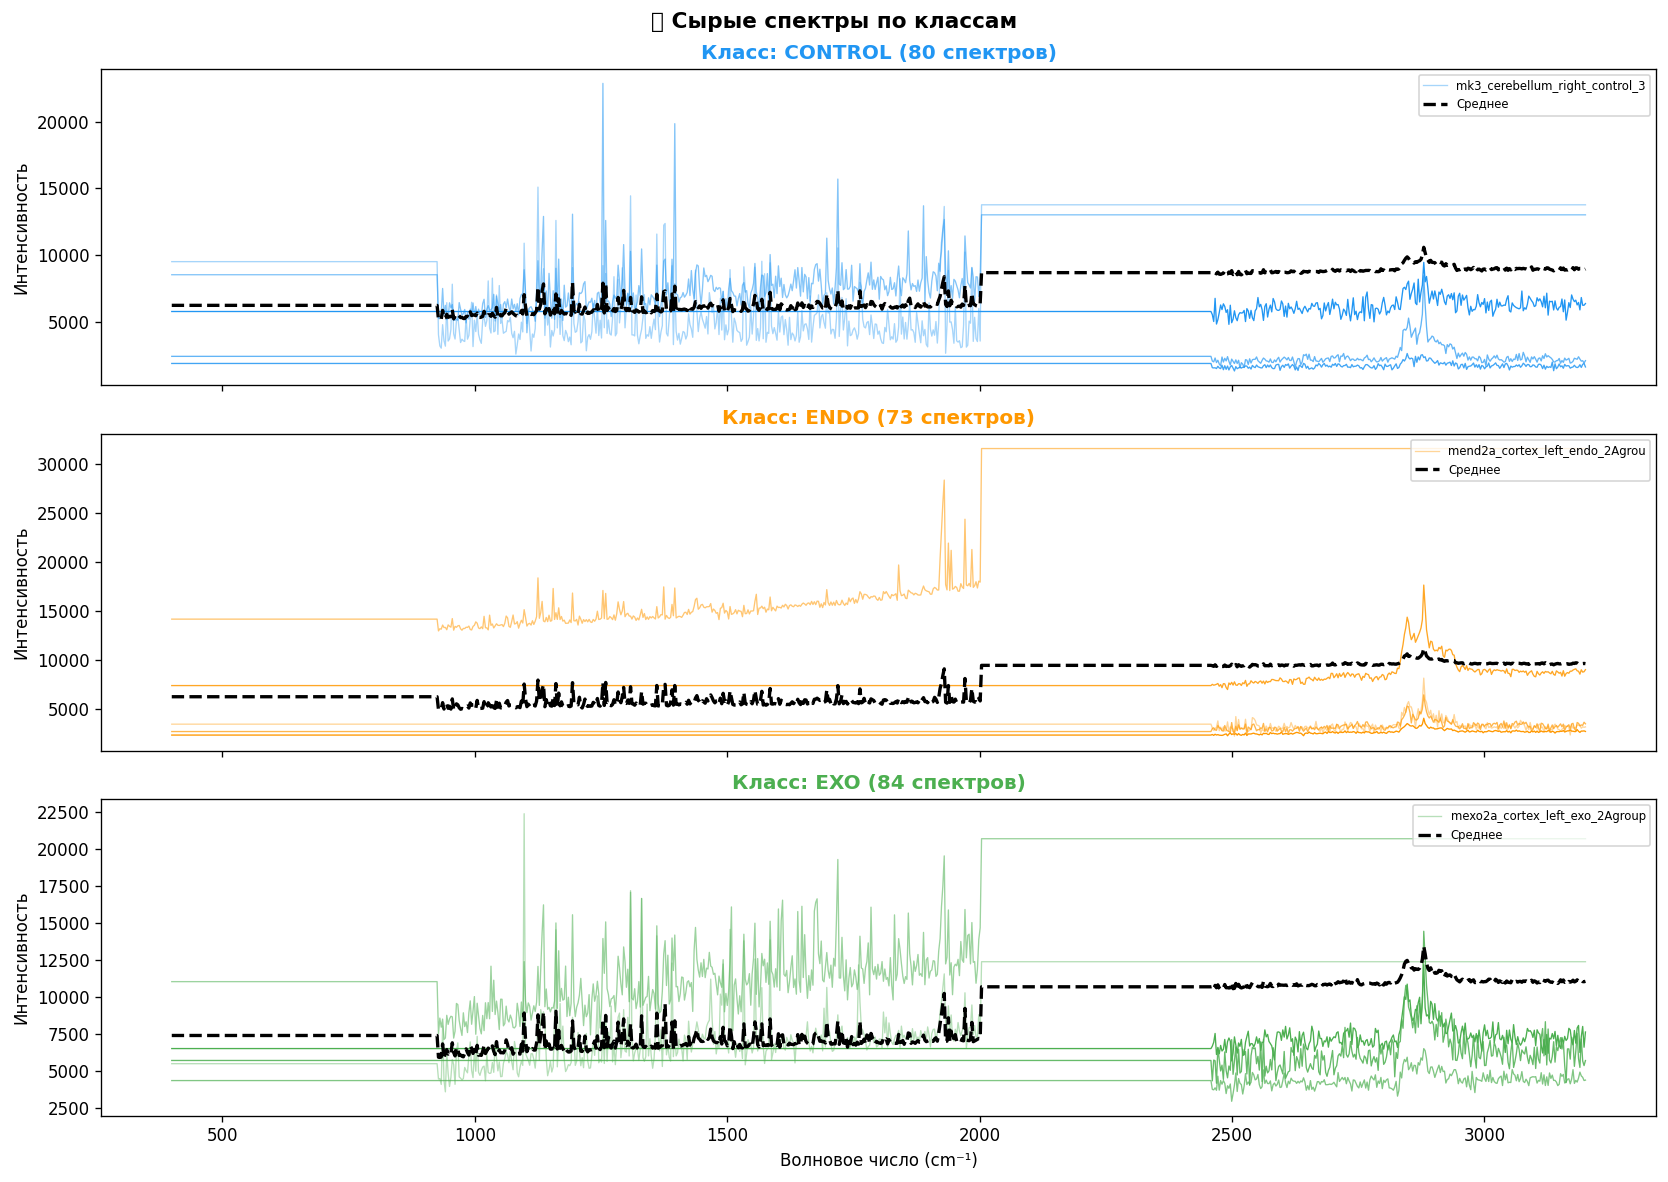

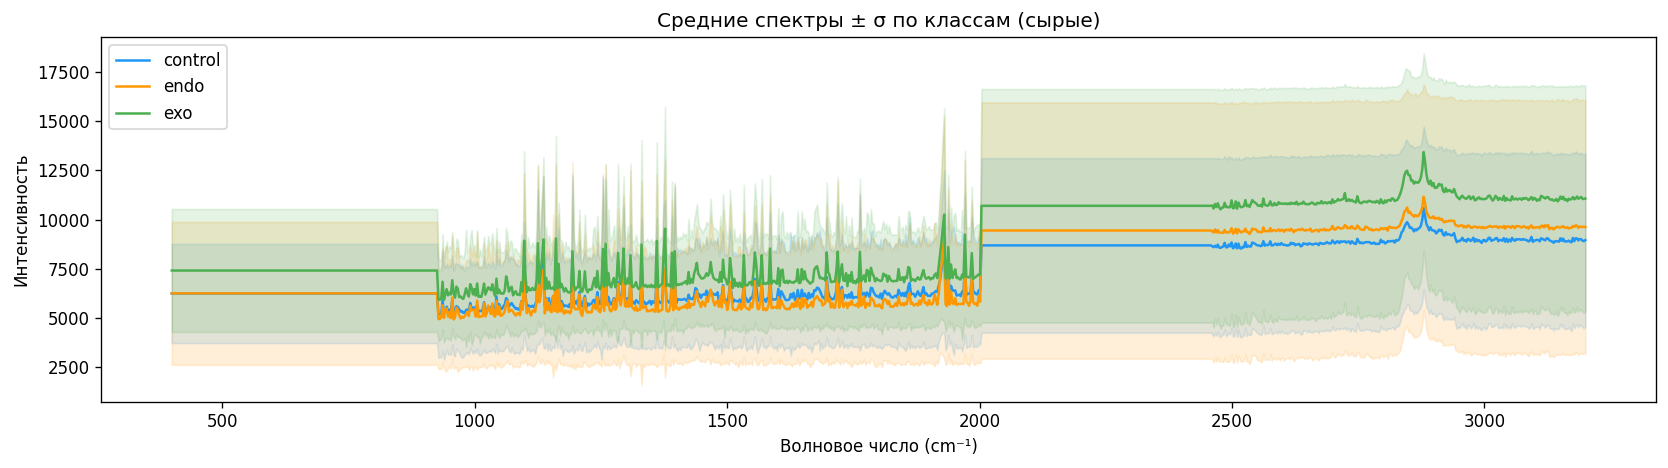

In [49]:
N_EXAMPLES = 5   # спектров на класс
fig, axes  = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, class_name in zip(axes, CLASS_NAMES):
    cls_data = [r for r in raw_data if r['class_name'] == class_name]
    sample   = cls_data[:N_EXAMPLES]
    alphas   = np.linspace(0.4, 1.0, N_EXAMPLES)

    for i, (rec, alpha) in enumerate(zip(sample, alphas)):
        ax.plot(rec['wave'], rec['intensity'],
                color=COLORS[class_name], alpha=alpha, lw=0.8,
                label=rec['filename'][:30] if i == 0 else '_')

    # Среднее по классу
    mean_spec = np.mean([r['intensity'] for r in cls_data], axis=0)
    ax.plot(WAVE_GRID, mean_spec, color='black', lw=2,
            ls='--', label='Среднее', zorder=5)

    ax.set_title(f'Класс: {class_name.upper()} ({len(cls_data)} спектров)',
                 color=COLORS[class_name], fontweight='bold')
    ax.set_ylabel('Интенсивность')
    ax.legend(loc='upper right', fontsize=7)

axes[-1].set_xlabel('Волновое число (cm⁻¹)')
plt.suptitle('📈 Сырые спектры по классам', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('raw_spectra_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Оверлей средних спектров всех классов ---
fig, ax = plt.subplots(figsize=(14, 4))
for class_name in CLASS_NAMES:
    cls_data  = [r for r in raw_data if r['class_name'] == class_name]
    mean_spec = np.mean([r['intensity'] for r in cls_data], axis=0)
    std_spec  = np.std([r['intensity']  for r in cls_data], axis=0)
    ax.plot(WAVE_GRID, mean_spec, color=COLORS[class_name], lw=1.5, label=class_name)
    ax.fill_between(WAVE_GRID,
                    mean_spec - std_spec,
                    mean_spec + std_spec,
                    color=COLORS[class_name], alpha=0.15)
ax.set_xlabel('Волновое число (cm⁻¹)')
ax.set_ylabel('Интенсивность')
ax.set_title('Средние спектры ± σ по классам (сырые)')
ax.legend()
plt.tight_layout()
plt.savefig('raw_mean_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

## ШАГ 2: Предобработка спектров

In [36]:
def savgol_smooth(y, window=11, polyorder=3):
    return savgol_filter(y, window_length=window, polyorder=polyorder)


# Кеш матрицы H: пересчитывается только при смене n или lam
_asls_cache = {}

def asls_baseline(y, lam=1e5, p=0.01, max_iter=10):
    """Asymmetric Least Squares baseline (Eilers & Boelens 2005)."""
    n = len(y)
    cache_key = (n, lam)
    if cache_key not in _asls_cache:
        D = diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
        _asls_cache[cache_key] = lam * D.T.dot(D)
    H = _asls_cache[cache_key]
    w = np.ones(n)
    for _ in range(max_iter):
        z = spsolve(diags(w, 0) + H, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z


def area_normalize(y):
    area = np.trapz(np.abs(y))
    return y / area if area > 1e-10 else y


def preprocess(intensity, lam=1e5, p=0.01):
    smoothed  = savgol_smooth(intensity)
    baseline  = asls_baseline(smoothed, lam=lam, p=p)
    corrected = np.clip(smoothed - baseline, 0, None)
    return area_normalize(corrected)


print('Предобработка...')
for r in tqdm(raw_data, desc='preprocessing'):
    r['intensity_proc'] = preprocess(r['intensity'])
print('Готово')

Предобработка...


preprocessing: 100%|██████████| 237/237 [00:05<00:00, 43.23it/s]

Готово


### ВИЗУАЛИЗАЦИЯ 3: Эффект предобработки (до / после)

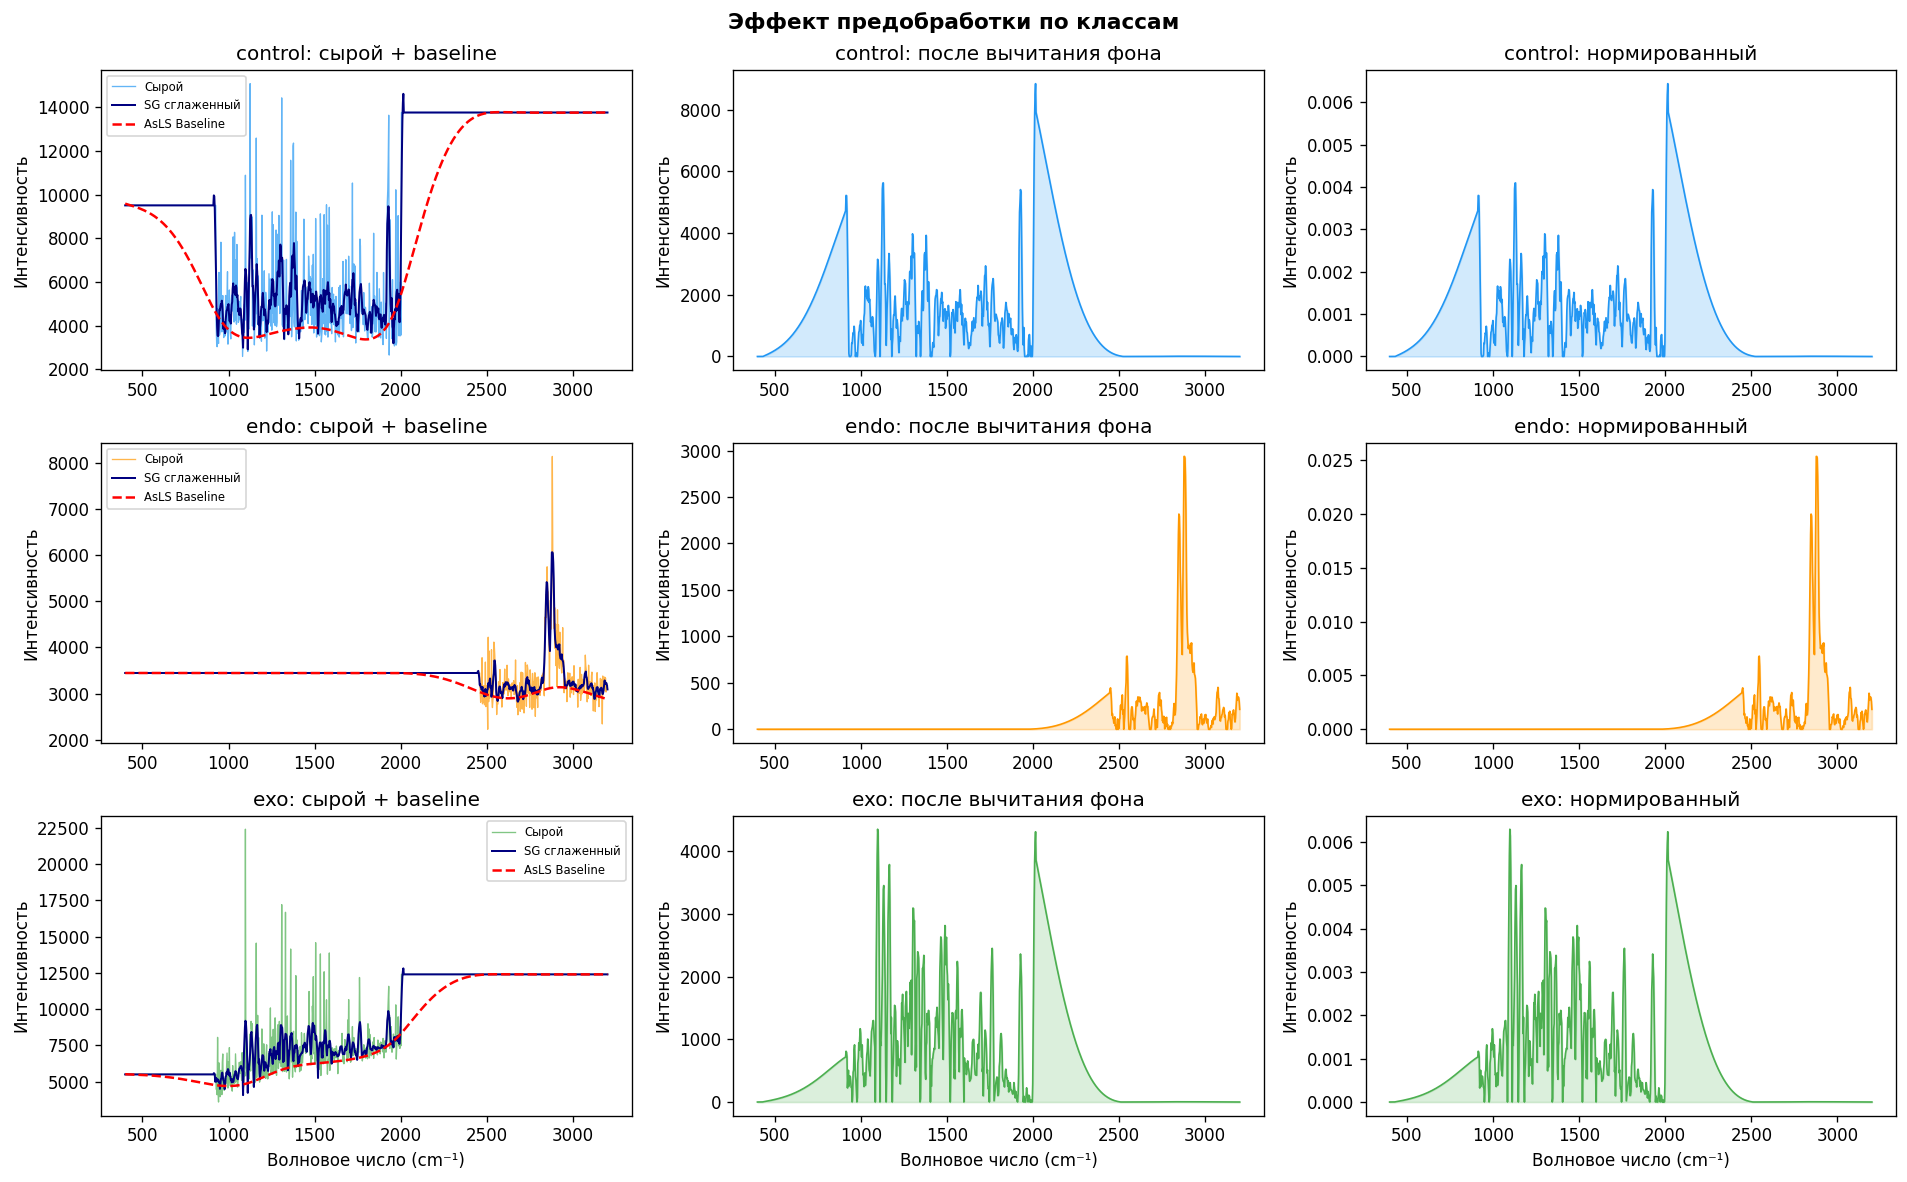

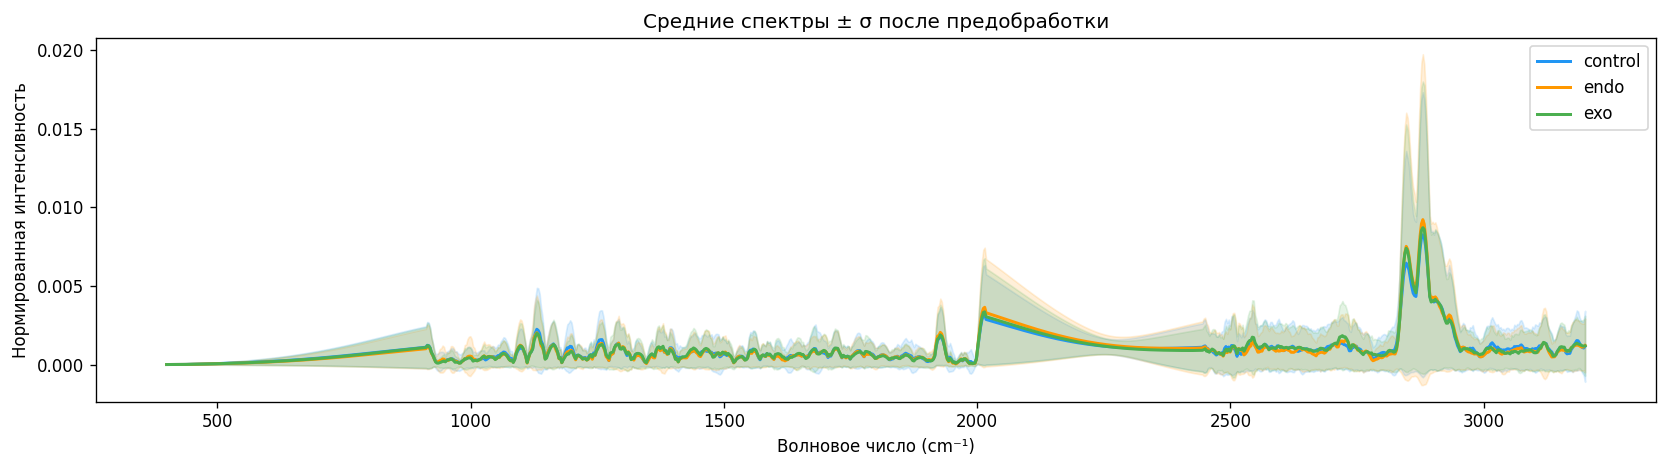

In [50]:
# Один пример на каждый класс
fig, axes = plt.subplots(3, 3, figsize=(16, 10))

for row, class_name in enumerate(CLASS_NAMES):
    ex       = next(r for r in raw_data if r['class_name'] == class_name)
    raw_i    = ex['intensity']
    smoothed = savgol_smooth(raw_i)
    baseline = asls_baseline(smoothed)
    corrected= np.clip(smoothed - baseline, 0, None)
    normed   = area_normalize(corrected)
    col      = COLORS[class_name]

    # Колонка 1: сырой + baseline
    ax = axes[row, 0]
    ax.plot(WAVE_GRID, raw_i,    color=col,   lw=0.8, alpha=0.7, label='Сырой')
    ax.plot(WAVE_GRID, smoothed, color='navy', lw=1.2, label='SG сглаженный')
    ax.plot(WAVE_GRID, baseline, color='red',  lw=1.5, ls='--', label='AsLS Baseline')
    ax.set_title(f'{class_name}: сырой + baseline')
    ax.legend(fontsize=7)
    ax.set_ylabel('Интенсивность')

    # Колонка 2: после вычитания baseline
    ax = axes[row, 1]
    ax.plot(WAVE_GRID, corrected, color=col, lw=1.0)
    ax.fill_between(WAVE_GRID, corrected, alpha=0.2, color=col)
    ax.set_title(f'{class_name}: после вычитания фона')
    ax.set_ylabel('Интенсивность')

    # Колонка 3: нормированный
    ax = axes[row, 2]
    ax.plot(WAVE_GRID, normed, color=col, lw=1.0)
    ax.fill_between(WAVE_GRID, normed, alpha=0.2, color=col)
    ax.set_title(f'{class_name}: нормированный')
    ax.set_ylabel('Интенсивность')

for ax in axes[-1, :]:
    ax.set_xlabel('Волновое число (cm⁻¹)')

plt.suptitle('Эффект предобработки по классам', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_effect.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Средние спектры ПОСЛЕ предобработки ---
fig, ax = plt.subplots(figsize=(14, 4))
for class_name in CLASS_NAMES:
    cls_data  = [r for r in raw_data if r['class_name'] == class_name]
    mean_spec = np.mean([r['intensity_proc'] for r in cls_data], axis=0)
    std_spec  = np.std([r['intensity_proc']  for r in cls_data], axis=0)
    ax.plot(WAVE_GRID, mean_spec, color=COLORS[class_name], lw=1.8, label=class_name)
    ax.fill_between(WAVE_GRID, mean_spec - std_spec, mean_spec + std_spec,
                    color=COLORS[class_name], alpha=0.15)
ax.set_xlabel('Волновое число (cm⁻¹)')
ax.set_ylabel('Нормированная интенсивность')
ax.set_title('Средние спектры ± σ после предобработки')
ax.legend()
plt.tight_layout()
plt.savefig('processed_mean_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

## ШАГ 3: Матрица признаков + стратифицированный групповой split

In [40]:
X      = np.array([r['intensity_proc'] for r in raw_data])
y      = np.array([r['target']         for r in raw_data])
groups = np.array([r['animal_id']      for r in raw_data])

print(f'X shape  : {X.shape}')
print(f'Классы   : {dict(zip(*np.unique(y, return_counts=True)))}')
print(f'Мышек    : {len(np.unique(groups))}')
print(f'   {sorted(np.unique(groups))}')

# Диагностика: сколько животных на класс?
print('\nМышек по классам:')
animal_classes = {}
for r in raw_data:
    animal_classes.setdefault(r['animal_id'], set()).add(r['class_name'])
for cn in CLASS_NAMES:
    animals_in_class = [a for a, cls in animal_classes.items() if cn in cls]
    print(f'  {cn:10s}: {len(animals_in_class)} животных → {sorted(animals_in_class)}')

# Проблема GroupShuffleSplit(test_size=0.2): при малом датасете он не гарантирует
# попадание всех классов в тест — можно получить support = 0 для целого класса,
# и все метрики будут бессмысленны.

np.random.seed(42)
train_idx_list = []
test_idx_list  = []

print('\nСтратифицированный групповой split:')
for cn, label in CLASS_LABELS.items():
    # все мышки данного класса
    cls_animals = sorted({r['animal_id'] for r in raw_data if r['class_name'] == cn})
    n_test      = max(1, round(len(cls_animals) * 0.2))  # минимум 1 животное в тест

    perm        = np.random.permutation(len(cls_animals))
    test_animals  = set(np.array(cls_animals)[perm[:n_test]])
    train_animals = set(np.array(cls_animals)[perm[n_test:]])

    for i, r in enumerate(raw_data):
        if r['class_name'] != cn:
            continue
        if r['animal_id'] in test_animals:
            test_idx_list.append(i)
        else:
            train_idx_list.append(i)

    print(f'  {cn:10s}: train={sorted(train_animals)}  |  test={sorted(test_animals)}')

train_idx = np.array(train_idx_list)
test_idx = np.array(test_idx_list)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
g_train = groups[train_idx]

print(f'\nTrain: {len(X_train)} спектров')
print(f'Классы в train: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'\nTest : {len(X_test)} спектров')
print(f'Классы в test : {dict(zip(*np.unique(y_test, return_counts=True)))}')

# Проверка отсутствия утечки
train_animals_set = set(groups[train_idx])
test_animals_set = set(groups[test_idx])
leak = train_animals_set & test_animals_set
if leak:
    print(f'\nУТЕЧКА ДАННЫХ! Одна мышь в обоих сплитах: {leak}')
else:
    print(f'\nData leakage отсутствует')

print('Standard Scaler')
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

X shape  : (237, 1024)
Классы   : {np.int64(0): np.int64(80), np.int64(1): np.int64(73), np.int64(2): np.int64(84)}
Мышек    : 12
   [np.str_('mend1'), np.str_('mend2a'), np.str_('mend2b'), np.str_('mend3'), np.str_('mexo1'), np.str_('mexo2a'), np.str_('mexo2b'), np.str_('mexo3'), np.str_('mk1'), np.str_('mk2a'), np.str_('mk2b'), np.str_('mk3')]

Мышек по классам:
  control   : 4 животных → ['mk1', 'mk2a', 'mk2b', 'mk3']
  endo      : 4 животных → ['mend1', 'mend2a', 'mend2b', 'mend3']
  exo       : 4 животных → ['mexo1', 'mexo2a', 'mexo2b', 'mexo3']

Стратифицированный групповой split:
  control   : train=[np.str_('mk1'), np.str_('mk2b'), np.str_('mk3')]  |  test=[np.str_('mk2a')]
  endo      : train=[np.str_('mend1'), np.str_('mend2b'), np.str_('mend3')]  |  test=[np.str_('mend2a')]
  exo       : train=[np.str_('mexo1'), np.str_('mexo2a'), np.str_('mexo2b')]  |  test=[np.str_('mexo3')]

Train: 165 спектров
Классы в train: {np.int64(0): np.int64(56), np.int64(1): np.int64(49), np.int6

##ШАГ 4: GroupKFold кросс-валидация

In [41]:
models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=None,
        min_samples_leaf=2, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        C=10, kernel='rbf', gamma='scale',
        class_weight='balanced',
        probability=True, random_state=42
    ),
}

gkf        = GroupKFold(n_splits=5)
cv_results = {}

print('GroupKFold CV (5 folds)...')
for name, model in models.items():
    scores = []
    for tr, val in gkf.split(X_train_sc, y_train, groups=g_train):
        model.fit(X_train_sc[tr], y_train[tr])
        pred = model.predict(X_train_sc[val])
        scores.append(balanced_accuracy_score(y_train[val], pred))
    cv_results[name] = scores
    print(f'  {name:15s}: {np.mean(scores):.3f} ± {np.std(scores):.3f}')

GroupKFold CV (5 folds)...
  RandomForest   : 0.066 ± 0.043
  XGBoost        : 0.104 ± 0.093
  SVM (RBF)      : 0.181 ± 0.124


## ШАГ 5: Финальное обучение + Ансамбль

In [43]:
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    print(f'{name}')

ensemble = VotingClassifier(estimators=list(models.items()), voting='soft')
ensemble.fit(X_train_sc, y_train)
print('Ансамбль (soft voting)')

all_models = {**models, 'Ансамбль': ensemble}
test_results = {}


print('РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ')

for name, model in all_models.items():
    pred = model.predict(X_test_sc)
    acc  = accuracy_score(y_test, pred)
    bacc = balanced_accuracy_score(y_test, pred)
    test_results[name] = {'acc': acc, 'bacc': bacc, 'pred': pred}
    print(f'\n{name}  |  Acc={acc:.3f}  |  Balanced Acc={bacc:.3f}')
    print(classification_report(y_test, pred,
                                  target_names=CLASS_NAMES, digits=3))

best_name = max(test_results, key=lambda k: test_results[k]['bacc'])
print(f'\nЛучшая модель оказалась: {best_name} (Balanced Acc={test_results[best_name]["bacc"]:.3f})')

RandomForest
XGBoost
SVM (RBF)
Ансамбль (soft voting)
РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ

RandomForest  |  Acc=0.250  |  Balanced Acc=0.250
              precision    recall  f1-score   support

     control      0.200     0.250     0.222        24
        endo      0.389     0.292     0.333        24
         exo      0.208     0.208     0.208        24

    accuracy                          0.250        72
   macro avg      0.266     0.250     0.255        72
weighted avg      0.266     0.250     0.255        72


XGBoost  |  Acc=0.250  |  Balanced Acc=0.250
              precision    recall  f1-score   support

     control      0.212     0.292     0.246        24
        endo      0.350     0.292     0.318        24
         exo      0.211     0.167     0.186        24

    accuracy                          0.250        72
   macro avg      0.258     0.250     0.250        72
weighted avg      0.258     0.250     0.250        72


SVM (RBF)  |  Acc=0.306  |  Balanced Acc=0.306
        

### ВИЗУАЛИЗАЦИЯ 4: Матрицы ошибок всех моделей

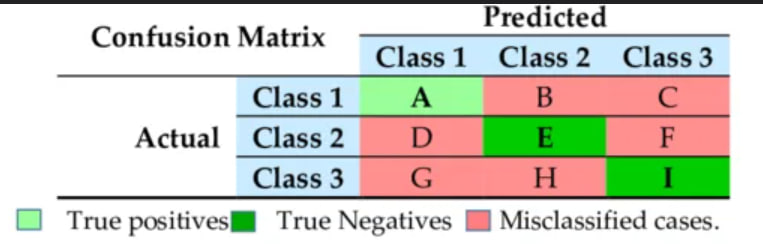

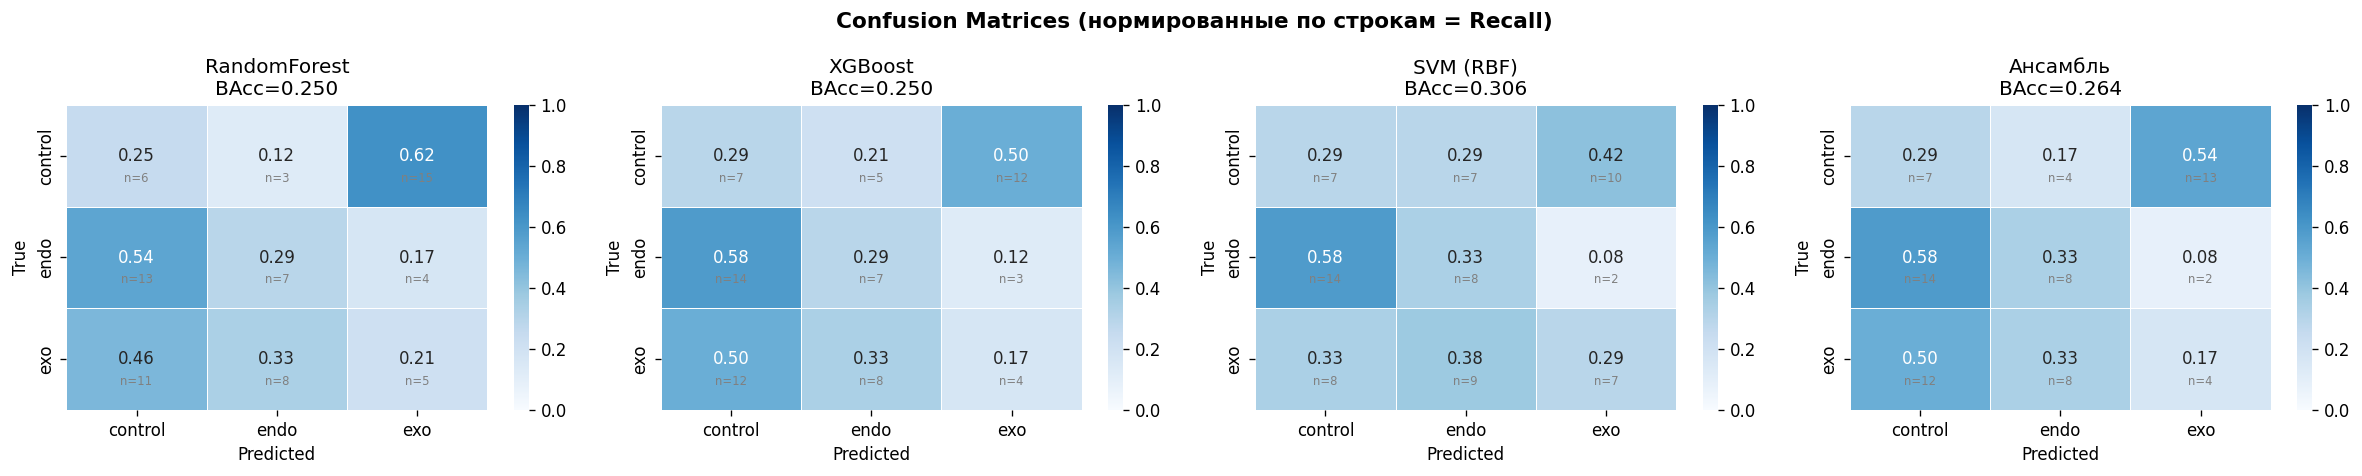

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, vmin=0, vmax=1)
    # Сырые числа поверх
    n_cls = cm.shape[0]
    for i in range(n_cls):
        for j in range(n_cls):
            ax.text(j + 0.5, i + 0.75, f'n={cm[i,j]}',
                    ha='center', fontsize=7, color='gray')

    ax.set_title(f'{name}\nBAcc={res["bacc"]:.3f}')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices (нормированные по строкам = Recall)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Шаг 6: Сохранение модели

In [47]:
import joblib

joblib.dump(ensemble, 'model.pkl')
print("Ансамбль сохранен как model.pkl")

# Скачивание при необходимости
# from google.colab import files
# files.download(model.pkl)

Ансамбль сохранен как model.pkl


### Пример использования сохраненной модели

In [53]:
# Загрузка сохраненной модели
loaded_ensemble = joblib.load('model.pkl')
print("Модель успешно загружена.")

dummy_new_data = np.random.rand(10, WAVE_GRID.shape[0])

# Масштабирование новых данных (используя тот же scaler, что и для тренировочных данных)
# Убедитесь, что `scaler` доступен в вашем окружении
if 'scaler' in globals():
    scaled_new_data = scaler.transform(dummy_new_data)
    print("Данные успешно масштабированы.")
else:
    print("Данные не были масштабированы.")
    scaled_new_data = dummy_new_data  # Продолжаем без масштабирования, если scaler отсутствует

# Предсказание классов для новых данных
predictions = loaded_ensemble.predict(scaled_new_data)

print("\nПредсказания для новых данных:")
for i, pred_label in enumerate(predictions):
    predicted_class_name = [name for name, label in CLASS_LABELS.items() if label == pred_label][0]
    print(f"Спектр {i+1}: Предсказанный класс = {predicted_class_name}")


Модель успешно загружена.
Данные успешно масштабированы.

Предсказания для новых данных:
Спектр 1: Предсказанный класс = exo
Спектр 2: Предсказанный класс = exo
Спектр 3: Предсказанный класс = exo
Спектр 4: Предсказанный класс = exo
Спектр 5: Предсказанный класс = exo
Спектр 6: Предсказанный класс = exo
Спектр 7: Предсказанный класс = exo
Спектр 8: Предсказанный класс = exo
Спектр 9: Предсказанный класс = exo
Спектр 10: Предсказанный класс = exo
